In [53]:
pwd

'C:\\Users\\Thirisha\\Documents\\project dataset'

In [54]:
cd C:\Users\Thirisha\Documents\project dataset

C:\Users\Thirisha\Documents\project dataset


In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [57]:
df=pd.read_csv('Clean_Dataset ( regreesion dataset).csv')
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [58]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [59]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [61]:
df.isnull()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,False,False,False,False,False,False,False,False,False,False,False,False
300149,False,False,False,False,False,False,False,False,False,False,False,False
300150,False,False,False,False,False,False,False,False,False,False,False,False
300151,False,False,False,False,False,False,False,False,False,False,False,False


In [62]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [63]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Unnamed: 0'>

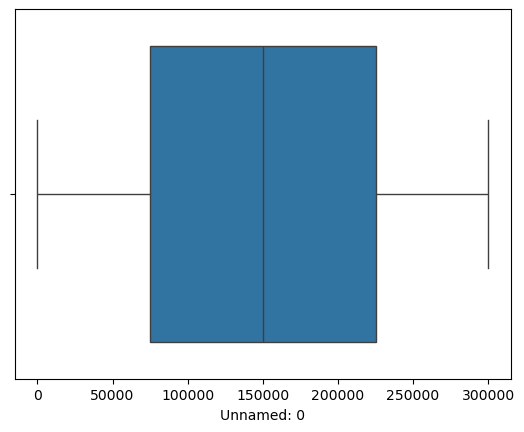

In [65]:
sns.boxplot(x='Unnamed: 0',data=df)

<Axes: xlabel='flight'>

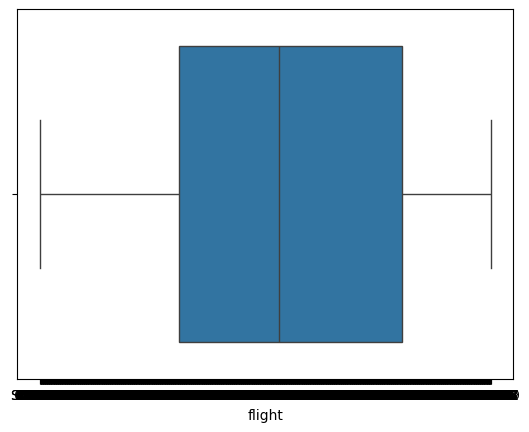

In [66]:
sns.boxplot(x='flight',data=df)

<Axes: xlabel='duration'>

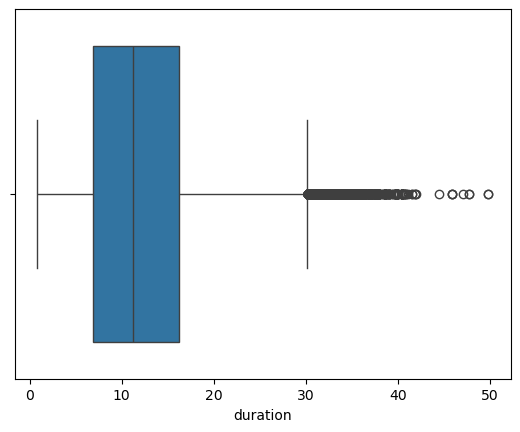

In [67]:
sns.boxplot(x='duration',data=df)

<Axes: xlabel='duration', ylabel='Count'>

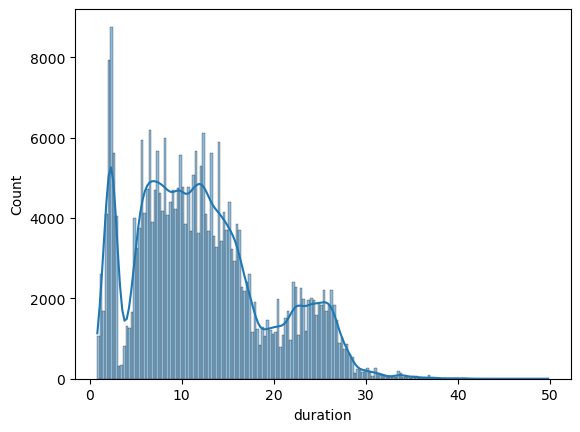

In [68]:
sns.histplot(x='duration',data=df,kde=True)

<Axes: xlabel='days_left'>

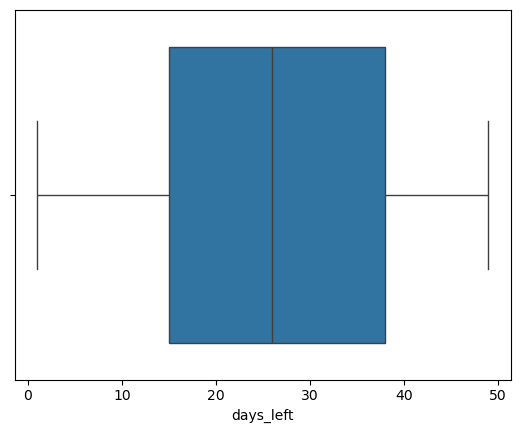

In [69]:
sns.boxplot(x='days_left',data=df)

<Axes: xlabel='price'>

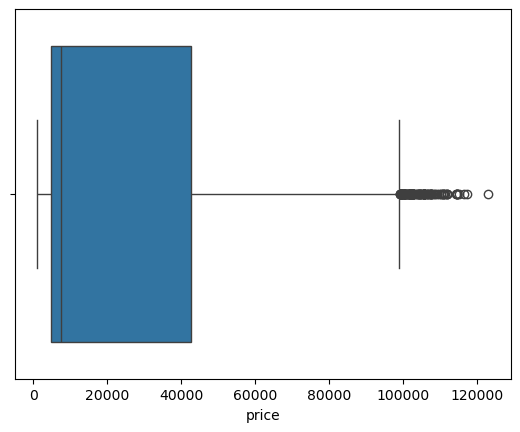

In [70]:
sns.boxplot(x='price',data=df)

<Axes: xlabel='price', ylabel='Count'>

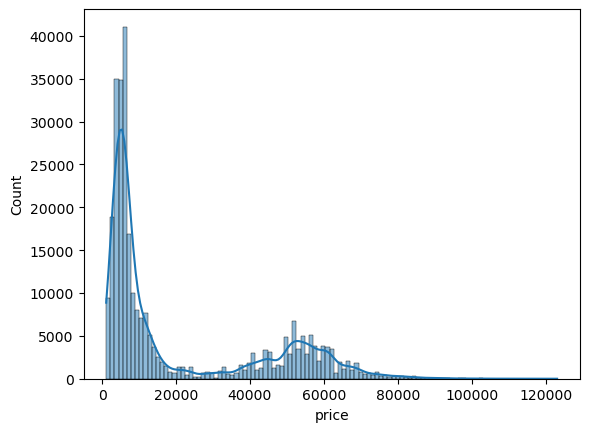

In [71]:
sns.histplot(x='price',data=df,kde=True)

In [72]:
def replace_outliers(dataframe,feature):
    q1=dataframe[feature].quantile(0.25)
    q3=dataframe[feature].quantile(0.75)
    iqr=q3-q1
    lower_range=q1-1.5*iqr
    upper_range=q3+1.5*iqr
    dataframe[feature]=np.where(dataframe[feature]<lower_range,lower_range,dataframe[feature])
    dataframe[feature]=np.where(dataframe[feature]>upper_range,upper_range,dataframe[feature])

In [73]:
df.shape

(300153, 12)

In [74]:
replace_outliers(df,'price')

<Axes: xlabel='price'>

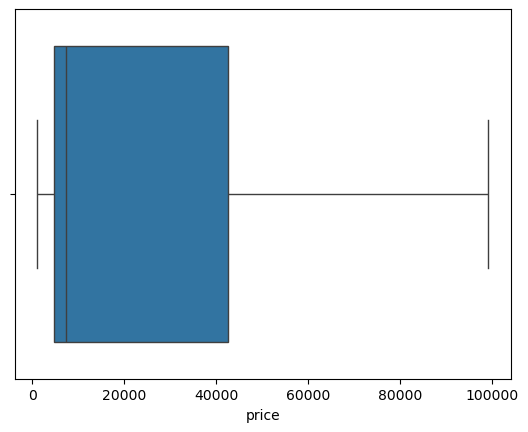

In [75]:
sns.boxplot(x='price',data=df)

In [76]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953.0
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953.0
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956.0
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955.0
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955.0
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265.0
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105.0
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099.0
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585.0


In [77]:
df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [78]:
import scipy.stats as stats

SpiceJet = df[df['airline'] == 'SpiceJet']['price']
AirAsia = df[df['airline'] == 'AirAsia']['price']
Vistara = df[df['airline'] == 'Vistara']['price']
GO_FIRST = df[df['airline'] == 'GO_FIRST']['price']
Indigo = df[df['airline'] == 'Indigo']['price']
Air_India = df[df['airline'] == 'Air_India']['price']

anova_result = stats.f_oneway(SpiceJet,AirAsia,Vistara,GO_FIRST,Indigo,Air_India)

print("P-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("yes")
else:
    print("no")

P-value: 0.0
yes


In [79]:
df['source_city'].unique()

array(['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai'],
      dtype=object)

In [80]:
import scipy.stats as stats

Delhi = df[df['source_city'] == 'Delhi']['price']
Mumbai = df[df['source_city'] == 'Mumbai']['price']
Bangalore = df[df['source_city'] == 'Bangalore']['price']
Kolkata = df[df['source_city'] == 'Kolkata']['price']
Hyderabad = df[df['source_city'] == 'Hyderabad']['price']
Chennai = df[df['source_city'] == 'Chennai']['price']

anova_result = stats.f_oneway(Delhi,Mumbai,Bangalore,Kolkata,Hyderabad,Chennai)

print("P-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("yes")
else:
    print("no")

P-value: 2.4749260111375518e-154
yes


In [81]:
df['departure_time'].unique()

array(['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night',
       'Late_Night'], dtype=object)

In [82]:
df['departure_time'].dtype

dtype('O')

In [83]:
Late_Night = df[df['departure_time'] == 'Late_Night']['price']

In [84]:
import scipy.stats as stats

Evening = df[df['departure_time'] == 'Evening']['price']
Early_Morning = df[df['departure_time'] == 'Early_Morning']['price']
Morning = df[df['departure_time'] == 'Morning']['price']
Afternoon = df[df['departure_time'] == 'Afternoon']['price']
Night = df[df['departure_time'] == 'Night']['price']
Late_Night = df[df['departure_time'] == 'Late_Night']['price']

anova_result = stats.f_oneway(Evening, Early_Morning, Morning, Afternoon, Night, Late_Night)

print("P-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("yes")
else:
    print("no")

P-value: 0.0
yes


In [85]:
df['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [86]:
import scipy.stats as stats

zero = df[df['stops'] == 'zero']['price']
one = df[df['stops'] == 'one']['price']
two_or_more = df[df['stops'] == 'two_or_more']['price']

anova_result = stats.f_oneway(zero,one,two_or_more)

print("P-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("yes")
else:
    print("no")

P-value: 0.0
yes


In [87]:
df['arrival_time'].unique()

array(['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening',
       'Late_Night'], dtype=object)

In [88]:
import scipy.stats as stats

Night = df[df['arrival_time'] == 'Night']['price']
Morning = df[df['arrival_time'] == 'Morning']['price']
Early_Morning = df[df['arrival_time'] == 'Early_Morning']['price']
Afternoon = df[df['arrival_time'] == 'Afternoon']['price']
Evening = df[df['arrival_time'] == 'Evening']['price']
Late_Night = df[df['arrival_time'] == 'Late_Night']['price']

anova_result = stats.f_oneway(Evening, Early_Morning, Morning, Afternoon, Night, Late_Night)

print("P-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("yes")
else:
    print("no")

P-value: 0.0
yes


In [89]:
df['destination_city'].unique()

array(['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi'],
      dtype=object)

In [90]:
import scipy.stats as stats

Mumbai = df[df['destination_city'] == 'Mumbai']['price']
Bangalore = df[df['destination_city'] == 'Bangalore']['price']
Kolkata = df[df['destination_city'] == 'Kolkata']['price']
Hyderabad = df[df['destination_city'] == 'Hyderabad']['price']
Chennai = df[df['destination_city'] == 'Chennai']['price']
Delhi = df[df['destination_city'] == 'Delhi']['price']

anova_result = stats.f_oneway(Mumbai,Bangalore,Kolkata,Hyderabad,Chennai,Delhi)

print("P-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("yes")
else:
    print("no")

P-value: 3.088842742725365e-206
yes


In [91]:
df['class'].unique()

array(['Economy', 'Business'], dtype=object)

In [92]:
import scipy.stats as stats

Economy = df[df['class'] == 'Economy']['price']
Business = df[df['class'] == 'Business']['price']

t_result = stats.ttest_ind(Mumbai, Bangalore)

print("P-value:", t_result.pvalue)

if t_result.pvalue < 0.05:
    print("yes")
else:
    print("no")

P-value: 0.11642218680955967
no


In [93]:
from sklearn.preprocessing import LabelEncoder 

In [94]:
h1=LabelEncoder()

In [95]:
df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [96]:
df['source_city'].unique()

array(['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai'],
      dtype=object)

In [97]:
df['departure_time'].unique()

array(['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night',
       'Late_Night'], dtype=object)

In [98]:
df['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [99]:
df['arrival_time'].unique()

array(['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening',
       'Late_Night'], dtype=object)

In [100]:
df['destination_city'].unique()

array(['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi'],
      dtype=object)

In [101]:
df['class'].unique()

array(['Economy', 'Business'], dtype=object)

In [102]:
df['flight'].unique()

array(['SG-8709', 'SG-8157', 'I5-764', ..., '6E-7127', '6E-7259',
       'AI-433'], shape=(1561,), dtype=object)

In [103]:
df['airline']=h1.fit_transform(df['airline'])
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,4,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953.0
1,1,4,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953.0
2,2,0,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956.0
3,3,5,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955.0
4,4,5,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955.0
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,5,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265.0
300149,300149,5,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105.0
300150,300150,5,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099.0
300151,300151,5,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585.0


In [104]:
df['source_city']=h1.fit_transform(df['source_city'])
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,4,SG-8709,2,Evening,zero,Night,Mumbai,Economy,2.17,1,5953.0
1,1,4,SG-8157,2,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953.0
2,2,0,I5-764,2,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956.0
3,3,5,UK-995,2,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955.0
4,4,5,UK-963,2,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955.0
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,5,UK-822,1,Morning,one,Evening,Hyderabad,Business,10.08,49,69265.0
300149,300149,5,UK-826,1,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105.0
300150,300150,5,UK-832,1,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099.0
300151,300151,5,UK-828,1,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585.0


In [105]:
df['departure_time']=h1.fit_transform(df['departure_time'])
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,4,SG-8709,2,2,zero,Night,Mumbai,Economy,2.17,1,5953.0
1,1,4,SG-8157,2,1,zero,Morning,Mumbai,Economy,2.33,1,5953.0
2,2,0,I5-764,2,1,zero,Early_Morning,Mumbai,Economy,2.17,1,5956.0
3,3,5,UK-995,2,4,zero,Afternoon,Mumbai,Economy,2.25,1,5955.0
4,4,5,UK-963,2,4,zero,Morning,Mumbai,Economy,2.33,1,5955.0
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,5,UK-822,1,4,one,Evening,Hyderabad,Business,10.08,49,69265.0
300149,300149,5,UK-826,1,0,one,Night,Hyderabad,Business,10.42,49,77105.0
300150,300150,5,UK-832,1,1,one,Night,Hyderabad,Business,13.83,49,79099.0
300151,300151,5,UK-828,1,1,one,Evening,Hyderabad,Business,10.00,49,81585.0


In [106]:
df['stops']=h1.fit_transform(df['stops'])
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,4,SG-8709,2,2,2,Night,Mumbai,Economy,2.17,1,5953.0
1,1,4,SG-8157,2,1,2,Morning,Mumbai,Economy,2.33,1,5953.0
2,2,0,I5-764,2,1,2,Early_Morning,Mumbai,Economy,2.17,1,5956.0
3,3,5,UK-995,2,4,2,Afternoon,Mumbai,Economy,2.25,1,5955.0
4,4,5,UK-963,2,4,2,Morning,Mumbai,Economy,2.33,1,5955.0
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,5,UK-822,1,4,0,Evening,Hyderabad,Business,10.08,49,69265.0
300149,300149,5,UK-826,1,0,0,Night,Hyderabad,Business,10.42,49,77105.0
300150,300150,5,UK-832,1,1,0,Night,Hyderabad,Business,13.83,49,79099.0
300151,300151,5,UK-828,1,1,0,Evening,Hyderabad,Business,10.00,49,81585.0


In [107]:
df['arrival_time']=h1.fit_transform(df['arrival_time'])
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,4,SG-8709,2,2,2,5,Mumbai,Economy,2.17,1,5953.0
1,1,4,SG-8157,2,1,2,4,Mumbai,Economy,2.33,1,5953.0
2,2,0,I5-764,2,1,2,1,Mumbai,Economy,2.17,1,5956.0
3,3,5,UK-995,2,4,2,0,Mumbai,Economy,2.25,1,5955.0
4,4,5,UK-963,2,4,2,4,Mumbai,Economy,2.33,1,5955.0
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,5,UK-822,1,4,0,2,Hyderabad,Business,10.08,49,69265.0
300149,300149,5,UK-826,1,0,0,5,Hyderabad,Business,10.42,49,77105.0
300150,300150,5,UK-832,1,1,0,5,Hyderabad,Business,13.83,49,79099.0
300151,300151,5,UK-828,1,1,0,2,Hyderabad,Business,10.00,49,81585.0


In [108]:
df['destination_city']=h1.fit_transform(df['destination_city'])
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,4,SG-8709,2,2,2,5,5,Economy,2.17,1,5953.0
1,1,4,SG-8157,2,1,2,4,5,Economy,2.33,1,5953.0
2,2,0,I5-764,2,1,2,1,5,Economy,2.17,1,5956.0
3,3,5,UK-995,2,4,2,0,5,Economy,2.25,1,5955.0
4,4,5,UK-963,2,4,2,4,5,Economy,2.33,1,5955.0
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,5,UK-822,1,4,0,2,3,Business,10.08,49,69265.0
300149,300149,5,UK-826,1,0,0,5,3,Business,10.42,49,77105.0
300150,300150,5,UK-832,1,1,0,5,3,Business,13.83,49,79099.0
300151,300151,5,UK-828,1,1,0,2,3,Business,10.00,49,81585.0


In [109]:
df['class']=h1.fit_transform(df['class'])
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,4,SG-8709,2,2,2,5,5,1,2.17,1,5953.0
1,1,4,SG-8157,2,1,2,4,5,1,2.33,1,5953.0
2,2,0,I5-764,2,1,2,1,5,1,2.17,1,5956.0
3,3,5,UK-995,2,4,2,0,5,1,2.25,1,5955.0
4,4,5,UK-963,2,4,2,4,5,1,2.33,1,5955.0
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,5,UK-822,1,4,0,2,3,0,10.08,49,69265.0
300149,300149,5,UK-826,1,0,0,5,3,0,10.42,49,77105.0
300150,300150,5,UK-832,1,1,0,5,3,0,13.83,49,79099.0
300151,300151,5,UK-828,1,1,0,2,3,0,10.00,49,81585.0


In [110]:
df = pd.get_dummies(df, columns=['class'], drop_first=True, dtype=int)
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,price,class_1
0,0,4,SG-8709,2,2,2,5,5,2.17,1,5953.0,1
1,1,4,SG-8157,2,1,2,4,5,2.33,1,5953.0,1
2,2,0,I5-764,2,1,2,1,5,2.17,1,5956.0,1
3,3,5,UK-995,2,4,2,0,5,2.25,1,5955.0,1
4,4,5,UK-963,2,4,2,4,5,2.33,1,5955.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,5,UK-822,1,4,0,2,3,10.08,49,69265.0,0
300149,300149,5,UK-826,1,0,0,5,3,10.42,49,77105.0,0
300150,300150,5,UK-832,1,1,0,5,3,13.83,49,79099.0,0
300151,300151,5,UK-828,1,1,0,2,3,10.00,49,81585.0,0


In [111]:
df['flight']=h1.fit_transform(df['flight'])
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,price,class_1
0,0,4,1408,2,2,2,5,5,2.17,1,5953.0,1
1,1,4,1387,2,1,2,4,5,2.33,1,5953.0,1
2,2,0,1213,2,1,2,1,5,2.17,1,5956.0,1
3,3,5,1559,2,4,2,0,5,2.25,1,5955.0,1
4,4,5,1549,2,4,2,4,5,2.33,1,5955.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,5,1477,1,4,0,2,3,10.08,49,69265.0,0
300149,300149,5,1481,1,0,0,5,3,10.42,49,77105.0,0
300150,300150,5,1486,1,1,0,5,3,13.83,49,79099.0,0
300151,300151,5,1483,1,1,0,2,3,10.00,49,81585.0,0


In [112]:
df.corr()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,price,class_1
Unnamed: 0,1.000000,0.179822,0.211121,-0.089653,0.087107,-0.123422,0.029329,0.020795,0.159007,0.014638,0.761336,-0.802099
airline,0.179822,1.000000,0.637918,-0.028350,0.056885,-0.029838,0.037714,-0.030172,-0.001651,-0.010678,0.243344,-0.178862
flight,0.211121,0.637918,1.000000,-0.009443,0.071564,-0.118833,0.067175,-0.036248,0.205502,-0.000443,0.305891,-0.259531
source_city,-0.089653,-0.028350,-0.009443,1.000000,-0.004688,0.001819,0.044153,-0.222935,0.008619,-0.003568,0.004571,0.000075
departure_time,0.087107,0.056885,0.071564,-0.004688,1.000000,-0.008518,-0.046282,-0.001761,0.084348,-0.001597,0.058320,-0.053340
stops,-0.123422,-0.029838,-0.118833,0.001819,-0.008518,1.000000,0.010515,-0.012846,-0.473860,-0.007047,-0.202687,0.100262
arrival_time,0.029329,0.037714,0.067175,0.044153,-0.046282,0.010515,1.000000,-0.037431,0.008679,-0.004191,0.042041,-0.027647
destination_city,0.020795,-0.030172,-0.036248,-0.222935,-0.001761,-0.012846,-0.037431,1.000000,0.001736,-0.005323,0.004792,0.001603
duration,0.159007,-0.001651,0.205502,0.008619,0.084348,-0.473860,0.008679,0.001736,1.000000,-0.039157,0.204258,-0.138710
days_left,0.014638,-0.010678,-0.000443,-0.003568,-0.001597,-0.007047,-0.004191,-0.005323,-0.039157,1.000000,-0.091845,0.013039


In [113]:
df = df.drop('Unnamed: 0', axis=1)

In [114]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,price,class_1
0,4,1408,2,2,2,5,5,2.17,1,5953.0,1
1,4,1387,2,1,2,4,5,2.33,1,5953.0,1
2,0,1213,2,1,2,1,5,2.17,1,5956.0,1
3,5,1559,2,4,2,0,5,2.25,1,5955.0,1
4,5,1549,2,4,2,4,5,2.33,1,5955.0,1
...,...,...,...,...,...,...,...,...,...,...,...
300148,5,1477,1,4,0,2,3,10.08,49,69265.0,0
300149,5,1481,1,0,0,5,3,10.42,49,77105.0,0
300150,5,1486,1,1,0,5,3,13.83,49,79099.0,0
300151,5,1483,1,1,0,2,3,10.00,49,81585.0,0


In [115]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
duration            0
days_left           0
price               0
class_1             0
dtype: int64

In [118]:
df1=df.copy()

In [119]:
df1

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,price,class_1
0,4,1408,2,2,2,5,5,2.17,1,5953.0,1
1,4,1387,2,1,2,4,5,2.33,1,5953.0,1
2,0,1213,2,1,2,1,5,2.17,1,5956.0,1
3,5,1559,2,4,2,0,5,2.25,1,5955.0,1
4,5,1549,2,4,2,4,5,2.33,1,5955.0,1
...,...,...,...,...,...,...,...,...,...,...,...
300148,5,1477,1,4,0,2,3,10.08,49,69265.0,0
300149,5,1481,1,0,0,5,3,10.42,49,77105.0,0
300150,5,1486,1,1,0,5,3,13.83,49,79099.0,0
300151,5,1483,1,1,0,2,3,10.00,49,81585.0,0


In [120]:
y=df1['price']
y

0          5953.0
1          5953.0
2          5956.0
3          5955.0
4          5955.0
           ...   
300148    69265.0
300149    77105.0
300150    79099.0
300151    81585.0
300152    81585.0
Name: price, Length: 300153, dtype: float64

In [121]:
x= df1.drop('price', axis=1)
x

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,class_1
0,4,1408,2,2,2,5,5,2.17,1,1
1,4,1387,2,1,2,4,5,2.33,1,1
2,0,1213,2,1,2,1,5,2.17,1,1
3,5,1559,2,4,2,0,5,2.25,1,1
4,5,1549,2,4,2,4,5,2.33,1,1
...,...,...,...,...,...,...,...,...,...,...
300148,5,1477,1,4,0,2,3,10.08,49,0
300149,5,1481,1,0,0,5,3,10.42,49,0
300150,5,1486,1,1,0,5,3,13.83,49,0
300151,5,1483,1,1,0,2,3,10.00,49,0


In [122]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=33)

In [123]:
x_train

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,class_1
59337,0,1215,5,1,0,2,0,11.42,37,1
3351,2,987,2,4,0,2,5,7.50,18,1
289092,5,1490,1,4,2,0,2,2.75,28,0
162515,5,1508,3,1,0,2,5,12.25,29,1
148740,3,380,4,0,0,5,1,8.17,10,1
...,...,...,...,...,...,...,...,...,...,...
147558,1,845,4,0,0,4,3,17.50,45,1
196665,2,1057,1,2,0,5,0,4.33,37,1
158921,5,1515,3,5,0,4,5,14.58,5,1
223890,5,1533,2,4,0,2,1,10.42,33,0


In [124]:
x_test

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,class_1
274991,1,828,3,5,0,4,2,12.50,7,0
164155,1,908,3,1,0,2,5,11.75,40,1
10702,1,723,2,2,0,4,0,17.33,5,1
89893,5,1513,0,5,0,4,2,12.00,30,1
94941,5,1465,0,1,0,2,5,12.08,7,1
...,...,...,...,...,...,...,...,...,...,...
127034,5,1459,4,0,2,2,2,2.42,47,1
173471,1,763,3,2,0,4,4,16.75,26,1
261640,1,849,4,2,0,5,2,6.50,8,0
152591,5,1515,3,5,2,5,2,2.25,2,1


In [125]:
y_train

59337      8148.0
3351      11011.0
289092    27792.0
162515     5375.0
148740    11860.0
           ...   
147558     5145.0
196665     2212.0
158921    10069.0
223890    52392.0
104152    11741.0
Name: price, Length: 240122, dtype: float64

In [126]:
## scaling
from sklearn.preprocessing import StandardScaler
model =StandardScaler()
x_train_scaled = model.fit_transform(x_train)
x_test_scaled = model.transform(x_test)

In [127]:
x_train_scaled

array([[-1.69584355,  0.29700091,  1.38274073, ..., -0.1121004 ,
         0.81222302,  0.67316681],
       [-0.60414705, -0.2370163 , -0.33002491, ..., -0.65695903,
        -0.58894594,  0.67316681],
       [ 1.0333977 ,  0.94110061, -0.90094678, ..., -1.31718314,
         0.14851141, -1.4855159 ],
       ...,
       [ 1.0333977 ,  0.99965513,  0.24089697, ...,  0.32712238,
        -1.54764048,  0.67316681],
       [ 1.0333977 ,  1.04181439, -0.33002491, ..., -0.25109495,
         0.51724008, -1.4855159 ],
       [-0.0582988 , -1.19028386, -1.47186866, ..., -0.59858132,
        -1.03142034,  0.67316681]], shape=(240122, 10))

In [128]:
x_test_scaled

array([[-1.1499953 , -0.60942304,  0.24089697, ...,  0.03801371,
        -1.40014901, -1.4855159 ],
       [-1.1499953 , -0.42204858,  0.24089697, ..., -0.0662322 ,
         1.03346022,  0.67316681],
       [-1.1499953 , -0.85535202, -0.33002491, ...,  0.70935739,
        -1.54764048,  0.67316681],
       ...,
       [-1.1499953 , -0.56023724,  0.81181885, ..., -0.79595358,
        -1.32640328, -1.4855159 ],
       [ 1.0333977 ,  0.99965513,  0.24089697, ..., -1.38668041,
        -1.76887769,  0.67316681],
       [ 1.0333977 ,  0.88723046, -1.47186866, ..., -0.33310173,
        -0.14647153, -1.4855159 ]], shape=(60031, 10))

In [129]:
model1 = LinearRegression()

In [130]:
model1.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [131]:
y_pred = model1.predict(x_test)

In [132]:
y_pred

array([53271.78463753,  4180.11627997,  8941.34473505, ...,
       52803.70687603,  5993.25757306, 54159.89901733], shape=(60031,))

In [133]:
y_test

274991    39499.0
164155     3288.0
10702     10680.0
89893      4796.0
94941     11205.0
           ...   
127034     4001.0
173471     4789.0
261640    53743.0
152591    10648.0
254310    62188.0
Name: price, Length: 60031, dtype: float64

In [134]:
from sklearn.metrics import r2_score
accurancy = r2_score(y_test,y_pred)
accurancy

0.9054999635616107

In [135]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 4600.391801107714
MSE : 48046987.18628619
RMSE : 6931.593408898577
R2 Score : 0.9054999635616107


In [136]:
## training_accuracy    
y_train_pred=model1.predict(x_train)
final_training=r2_score(y_train_pred,y_train)
final_training

0.8948264348724426

In [137]:
## testing_accuracy
y_pred=model1.predict(x_test)
final_result=r2_score(y_test,y_pred)
final_result

0.9054999635616107

In [133]:
# svr

In [134]:
from sklearn.svm import SVR
svm1 = SVR()

In [135]:
svm1.fit(x_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [136]:
y_pred=svm1.predict(x_test)

In [137]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

In [138]:
## training_accuracy    
y_train_pred=svm1.predict(x_train)
final_training=r2_score(y_train_pred,y_train)
final_training

-158.01248051927638

In [139]:
## testing_accuracy
y_pred=svm1.predict(x_test)
final_result=r2_score(y_test,y_pred)
final_result

-0.26357738580935

In [140]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 15703.4222946814
MSE : 642445111.6952138
RMSE : 25346.500975385414
R2 Score : -0.26357738580935


In [138]:
# KNN 

In [139]:
## training the model 
from sklearn.neighbors import KNeighborsRegressor

# training the model
model = KNeighborsRegressor()
model1 = KNeighborsRegressor(n_neighbors=5)
model2 = KNeighborsRegressor(n_neighbors=7)
model3 = KNeighborsRegressor(n_neighbors=3, metric="manhattan")
model4 = KNeighborsRegressor(n_neighbors=5, metric="manhattan")
model5 = KNeighborsRegressor(n_neighbors=7, metric="manhattan")

In [140]:
model.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [141]:
y_pred=model.predict(x_test)

In [142]:
from sklearn.metrics import r2_score
accuracy = r2_score(y_test, y_pred)
accuracy

0.4439797816637139

In [143]:
model1.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [144]:
y_pred=model1.predict(x_test)

In [145]:
from sklearn.metrics import r2_score
accuracy = r2_score(y_test, y_pred)
accuracy

0.4439797816637139

In [146]:
model2.fit(x_train,y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [147]:
y_pred=model2.predict(x_test)

In [148]:
from sklearn.metrics import r2_score
accuracy = r2_score(y_test, y_pred)
accuracy

0.45415925649008415

In [149]:
model3.fit(x_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [150]:
y_pred=model3.predict(x_test)

In [151]:
from sklearn.metrics import r2_score
accuracy = r2_score(y_test, y_pred)
accuracy

0.6323007234580655

In [152]:
model4.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [153]:
y_pred=model4.predict(x_test)

In [154]:
from sklearn.metrics import r2_score
accuracy = r2_score(y_test, y_pred)
accuracy

0.6131279633947515

In [155]:
model5.fit(x_train,y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [156]:
y_pred=model5.predict(x_test)

In [157]:
from sklearn.metrics import r2_score
accuracy = r2_score(y_test, y_pred)
accuracy

0.6095270725825588

In [158]:
y_pred=model3.predict(x_test)

In [159]:
from sklearn.metrics import r2_score
accuracy = r2_score(y_test, y_pred)
accuracy

0.6323007234580655

In [160]:
## training_accuracy    
y_train_pred=model3.predict(x_train)
final_training=r2_score(y_train_pred,y_train)
final_training 

0.6939549963847235

In [161]:
# testing accuracy
y_pred=model3.predict(x_test)
final_result=r2_score(y_test,y_pred)
final_result

0.6323007234580655

In [162]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 9229.938587285456
MSE : 186950641.44165885
RMSE : 13672.989484441903
R2 Score : 0.6323007234580655


In [163]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,price,class_1
0,4,1408,2,2,2,5,5,2.17,1,5953.0,1
1,4,1387,2,1,2,4,5,2.33,1,5953.0,1
2,0,1213,2,1,2,1,5,2.17,1,5956.0,1
3,5,1559,2,4,2,0,5,2.25,1,5955.0,1
4,5,1549,2,4,2,4,5,2.33,1,5955.0,1
...,...,...,...,...,...,...,...,...,...,...,...
300148,5,1477,1,4,0,2,3,10.08,49,69265.0,0
300149,5,1481,1,0,0,5,3,10.42,49,77105.0,0
300150,5,1486,1,1,0,5,3,13.83,49,79099.0,0
300151,5,1483,1,1,0,2,3,10.00,49,81585.0,0


In [164]:
y=df['price']
y

0          5953.0
1          5953.0
2          5956.0
3          5955.0
4          5955.0
           ...   
300148    69265.0
300149    77105.0
300150    79099.0
300151    81585.0
300152    81585.0
Name: price, Length: 300153, dtype: float64

In [165]:
x= df.drop('price', axis=1)
x

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,class_1
0,4,1408,2,2,2,5,5,2.17,1,1
1,4,1387,2,1,2,4,5,2.33,1,1
2,0,1213,2,1,2,1,5,2.17,1,1
3,5,1559,2,4,2,0,5,2.25,1,1
4,5,1549,2,4,2,4,5,2.33,1,1
...,...,...,...,...,...,...,...,...,...,...
300148,5,1477,1,4,0,2,3,10.08,49,0
300149,5,1481,1,0,0,5,3,10.42,49,0
300150,5,1486,1,1,0,5,3,13.83,49,0
300151,5,1483,1,1,0,2,3,10.00,49,0


In [166]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=33)

In [167]:
x_train

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,class_1
59337,0,1215,5,1,0,2,0,11.42,37,1
3351,2,987,2,4,0,2,5,7.50,18,1
289092,5,1490,1,4,2,0,2,2.75,28,0
162515,5,1508,3,1,0,2,5,12.25,29,1
148740,3,380,4,0,0,5,1,8.17,10,1
...,...,...,...,...,...,...,...,...,...,...
147558,1,845,4,0,0,4,3,17.50,45,1
196665,2,1057,1,2,0,5,0,4.33,37,1
158921,5,1515,3,5,0,4,5,14.58,5,1
223890,5,1533,2,4,0,2,1,10.42,33,0


In [168]:
x_test

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,duration,days_left,class_1
274991,1,828,3,5,0,4,2,12.50,7,0
164155,1,908,3,1,0,2,5,11.75,40,1
10702,1,723,2,2,0,4,0,17.33,5,1
89893,5,1513,0,5,0,4,2,12.00,30,1
94941,5,1465,0,1,0,2,5,12.08,7,1
...,...,...,...,...,...,...,...,...,...,...
127034,5,1459,4,0,2,2,2,2.42,47,1
173471,1,763,3,2,0,4,4,16.75,26,1
261640,1,849,4,2,0,5,2,6.50,8,0
152591,5,1515,3,5,2,5,2,2.25,2,1


In [169]:
y_train

59337      8148.0
3351      11011.0
289092    27792.0
162515     5375.0
148740    11860.0
           ...   
147558     5145.0
196665     2212.0
158921    10069.0
223890    52392.0
104152    11741.0
Name: price, Length: 240122, dtype: float64

In [170]:
# Decision tree

In [171]:
dec1=DecisionTreeRegressor()

In [172]:
dec1.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [173]:
y_pred=dec1.predict(x_test)

In [174]:
from sklearn.metrics import r2_score
accuracy = r2_score(y_test, y_pred)
accuracy

0.9841480346993781

In [175]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 864.5123019773117
MSE : 8059670.687777981
RMSE : 2838.9559150818072
R2 Score : 0.9841480346993781


In [176]:
## training_accuracy    
y_train_pred=dec1.predict(x_train)
final_training=r2_score(y_train_pred,y_train)
final_training 

0.999894330463041

In [177]:
# testing accuracy
y_pred=dec1.predict(x_test)
final_result=r2_score(y_test,y_pred)
final_result

0.9841480346993781

In [178]:
# random foreset

In [179]:
rf_model = RandomForestRegressor(max_depth=10,min_samples_leaf=1,min_samples_split=6,n_estimators=361,random_state=42)

In [180]:
rf_model.fit(x_train, y_train)

,n_estimators,361
,criterion,'squared_error'
,max_depth,10
,min_samples_split,6
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [181]:
from sklearn.metrics import r2_score

y_pred = rf_model.predict(x_test)

accuracy = r2_score(y_test, y_pred)
print("Model R2 Score:", accuracy)

Model R2 Score: 0.9704465364234066


In [182]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 2186.9707717163537
MSE : 15025971.833362391
RMSE : 3876.334845361323
R2 Score : 0.9704465364234066


In [183]:
## training_accuracy    
y_train_pred=rf_model.predict(x_train)
final_training=r2_score(y_train_pred,y_train)
final_training 

0.9692635642402662

In [184]:
# testing accuracy
y_pred=rf_model.predict(x_test)
final_result=r2_score(y_test,y_pred)
final_result

0.9704465364234066

In [ ]:
# not use 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor

param_dist = {'n_estimators': randint(50, 500),'max_depth': [3, 5, 10],'min_samples_split': [2, 5, 6, 7, 3, 10],'min_samples_leaf': [1, 2, 3, 4]}

rf = RandomForestRegressor()

rand_search = RandomizedSearchCV(rf,param_distributions=param_dist,n_iter=5,cv=5,scoring='r2',verbose=1,n_jobs=-1)

rand_search.fit(x_train, y_train)

print("Best Hyperparameters:")
print(rand_search.best_params_)

In [132]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

xgb = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=2)

xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)

print("XGBoost R2 Score:", r2_score(y_test, y_pred))


XGBoost R2 Score: 0.9491321217610326


In [ ]:
report = {
    'SNO': [1, 2, 3,4,5,6],
    'ALGORITHMS': ['Logestic Regression','K-Nearest Neighbors (KNN)','Support Vector Machine (SVM)','Decision Tree ','Navie Bias','XGBoost'],
    'ACCURACY': ['79%','76%','80%','80%','79%','86%'],
    'PERFORMANCE': ['Good Accuracy','Good Accuracy','Good Accuracy','Good Accuracy','Good Accuracy','Best Accuracy(86%)']}
    

final_report= pd.DataFrame(report)
final_report